Total archivos: 1
Tamaño total:   0.00 GB

CSV                                                          0.0 MB


In [2]:
import os

carpeta = r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz"

for archivo in os.listdir(carpeta):
    ruta = os.path.join(carpeta, archivo)
    tam  = os.path.getsize(ruta) / (1024**3)
    print(f"{archivo:<50} {tam:.2f} GB")

ana                                                0.00 GB
analisisde                                         0.00 GB
analisis_capas_2_3.png                             0.00 GB
analisis_de_datos.ipynb                            0.00 GB
analisis_de_datos2.ipynb                           0.00 GB
analisis_de_datos_prac.ipynb                       0.00 GB
atacante.ipynb                                     0.00 GB
atk_labels.npy                                     0.01 GB
atk_raw.npy                                        0.01 GB
benign_raw.npy                                     0.16 GB
CSV                                                0.00 GB
CSV.zip                                            1.33 GB
distribucion_clases.png                            0.00 GB
division_datos.png                                 0.00 GB
features_comparacion.png                           0.00 GB
features_por_grupo.png                             0.00 GB
grafica_anomalia.png                               0.00 

In [3]:
import os

carpeta_csv = r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz\CSV"

archivos = []
for archivo in os.listdir(carpeta_csv):
    ruta  = os.path.join(carpeta_csv, archivo)
    tam   = os.path.getsize(ruta) / (1024**2)  # en MB
    archivos.append((archivo, tam))

archivos.sort(key=lambda x: x[1], reverse=True)

total = sum(t for _, t in archivos)
print(f"Total archivos: {len(archivos)}")
print(f"Tamaño total:   {total/1024:.2f} GB\n")

for nombre, tam in archivos[:20]:  # primeros 20
    print(f"{nombre:<60} {tam:.1f} MB")

Total archivos: 1
Tamaño total:   0.00 GB

CSV                                                          0.0 MB


In [10]:
import os

raiz = r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz"

print("Explorando toda la estructura de carpetas:\n")

for dirpath, dirnames, filenames in os.walk(raiz):
    nivel = dirpath.replace(raiz, '').count(os.sep)
    sangria = '  ' * nivel
    print(f"{sangria}{os.path.basename(dirpath)}/")
    
    for archivo in filenames:
        ruta = os.path.join(dirpath, archivo)
        tam  = os.path.getsize(ruta) / (1024**2)
        print(f"{sangria}  {archivo:<50} {tam:.1f} MB")

Explorando toda la estructura de carpetas:

Notebooks_IaTesisz/
  analisis_de_datos.ipynb                            0.0 MB
  atacante.ipynb                                     0.0 MB
  CSV.zip                                            1364.0 MB
  grafica_anomalia.png                               0.1 MB
  ids_logs.csv                                       1.1 MB
  simulacion_ataque.csv                              0.1 MB
  simulacion_v2.csv                                  0.0 MB
  testeo_de_anomalia.ipynb                           0.4 MB
  trafico_capturado.csv                              0.2 MB
  CSV/
    CSV/
      README_CSV.pdf                                     0.1 MB
      Backdoor_Malware/
        Backdoor_Malware.pcap.csv                          0.6 MB
      Benign_Final/
        BenignTraffic.pcap.csv                             71.6 MB
        BenignTraffic1.pcap.csv                            58.4 MB
        BenignTraffic2.pcap.csv                            61.2 MB
  

In [18]:
import numpy as np
import pandas as pd
import os, time, warnings
warnings.filterwarnings('ignore')

RUTA_CSV = r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz\CSV\CSV"
SALIDA   = r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz"

inicio        = time.time()
conteo_clases = {}
benign_parts  = []
attack_parts  = []

for carpeta in sorted(os.listdir(RUTA_CSV)):
    ruta_carpeta = os.path.join(RUTA_CSV, carpeta)
    if not os.path.isdir(ruta_carpeta):
        continue

    etiqueta = carpeta
    archivos = sorted([f for f in os.listdir(ruta_carpeta)
                       if f.endswith('.csv')])
    if not archivos:
        continue

    total_carpeta = 0
    partes_numpy  = []

    for arch in archivos:
        try:
            tmp = pd.read_csv(
                os.path.join(ruta_carpeta, arch),
                low_memory=False
            )
            # Convertir a numpy float32 INMEDIATAMENTE
            arr = tmp.values.astype(np.float32)
            # Limpiar inf/nan en numpy (sin copias pandas)
            mask = np.isfinite(arr).all(axis=1)
            arr  = arr[mask]
            total_carpeta += len(arr)
            partes_numpy.append(arr)
            del tmp, arr

        except Exception as e:
            print(f"  Error {arch}: {e}")

    if not partes_numpy:
        continue

    arr_total = np.concatenate(partes_numpy, axis=0)
    del partes_numpy
    conteo_clases[etiqueta] = total_carpeta

    if 'Benign' in etiqueta:
        benign_parts.append(arr_total)
        print(f"✅ {etiqueta:<35} {total_carpeta:>8,}")
    else:
        # Solo 2000 muestras
        n   = min(2000, len(arr_total))
        idx = np.random.choice(len(arr_total), n, replace=False)
        attack_parts.append((etiqueta, arr_total[idx]))
        print(f"⚔️  {etiqueta:<35} {total_carpeta:>8,} → {n}")

    del arr_total

# Guardar
print("\nGuardando archivos .npy...")
X_benign = np.concatenate(benign_parts, axis=0)
np.save(os.path.join(SALIDA, 'benign_raw.npy'), X_benign)
print(f"✓ benign_raw.npy  {X_benign.shape}")

X_atk    = np.concatenate([a for _, a in attack_parts], axis=0)
y_atk    = np.array([lab for lab, arr in attack_parts
                     for _ in range(len(arr))])
np.save(os.path.join(SALIDA, 'atk_raw.npy'),    X_atk)
np.save(os.path.join(SALIDA, 'atk_labels.npy'), y_atk)
print(f"✓ atk_raw.npy     {X_atk.shape}")
print(f"✓ atk_labels.npy  {y_atk.shape}")

print(f"\nTiempo: {time.time()-inicio:.1f}s")
total_r   = sum(conteo_clases.values())
benigno_r = sum(v for k,v in conteo_clases.items() if 'Benign' in k)
print(f"\nTotal en disco:  {total_r:,}")
print(f"Benigno:         {benigno_r:,}  ({benigno_r/total_r*100:.2f}%)")
print(f"Ataque:          {total_r-benigno_r:,}  ({(total_r-benigno_r)/total_r*100:.2f}%)")

⚔️  Backdoor_Malware                       3,218 → 2000
✅ Benign_Final                        1,098,126
⚔️  BrowserHijacking                       5,859 → 2000
⚔️  CommandInjection                       5,409 → 2000
⚔️  DDoS-ACK_Fragmentation               285,045 → 2000
⚔️  DDoS-HTTP_Flood                       28,790 → 2000
⚔️  DDoS-ICMP_Flood                     7,200,436 → 2000
⚔️  DDoS-ICMP_Fragmentation              452,444 → 2000
⚔️  DDoS-PSHACK_FLOOD                   4,094,727 → 2000
⚔️  DDoS-RSTFINFLOOD                    4,045,248 → 2000
⚔️  DDoS-SYN_Flood                      4,059,097 → 2000
⚔️  DDoS-SlowLoris                        23,425 → 2000
⚔️  DDoS-SynonymousIP_Flood             3,598,100 → 2000
⚔️  DDoS-TCP_Flood                      4,497,546 → 2000
⚔️  DDoS-UDP_Flood                      5,412,169 → 2000
⚔️  DDoS-UDP_Fragmentation               286,895 → 2000
⚔️  DNS_Spoofing                         178,893 → 2000
⚔️  DictionaryBruteForce                  13,064 

In [3]:
# Cargar los archivos guardados
import numpy as np

SALIDA = r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz"

X_benign = np.load(SALIDA + r'\benign_raw.npy')
X_atk    = np.load(SALIDA + r'\atk_raw.npy')
y_atk    = np.load(SALIDA + r'\atk_labels.npy', allow_pickle=True)

print(f"Benigno: {X_benign.shape}")
print(f"Ataques: {X_atk.shape}")
print(f"Labels:  {y_atk.shape}")
print(f"\nEjemplo de etiquetas: {np.unique(y_atk)[:5]}")

Benigno: (1098126, 39)
Ataques: (65252, 39)
Labels:  (65252,)

Ejemplo de etiquetas: ['Backdoor_Malware' 'BrowserHijacking' 'CommandInjection'
 'DDoS-ACK_Fragmentation' 'DDoS-HTTP_Flood']


In [4]:
# División 70/15/15
from sklearn.model_selection import train_test_split

X_train, X_temp = train_test_split(
    X_benign, test_size=0.30, random_state=42)
X_val, X_test_benign = train_test_split(
    X_temp, test_size=0.50, random_state=42)
del X_temp

total = len(X_benign)
print(f"Train (70%):  {len(X_train):,}")
print(f"Val   (15%):  {len(X_val):,}")
print(f"Test  (15%):  {len(X_test_benign):,}")

Train (70%):  768,688
Val   (15%):  164,719
Test  (15%):  164,719


In [6]:
# Normalización MinMax — fit SOLO en train
from sklearn.preprocessing import MinMaxScaler
import joblib

scaler           = MinMaxScaler()
X_train_scaled   = scaler.fit_transform(X_train)
X_val_scaled     = scaler.transform(X_val)
X_test_scaled    = scaler.transform(X_test_benign)
X_atk_scaled     = scaler.transform(X_atk)

# Guardar scaler para usarlo después en inferencia
joblib.dump(scaler, SALIDA + r'\scaler.pkl')

print(f"Train: {X_train_scaled.shape}")
print(f"Val:   {X_val_scaled.shape}")
print(f"Test:  {X_test_scaled.shape}")
print(f"Atk:   {X_atk_scaled.shape}")
print(f"Rango: min={X_train_scaled.min():.3f} max={X_train_scaled.max():.3f}")
print("Scaler guardado")

Train: (768688, 39)
Val:   (164719, 39)
Test:  (164719, 39)
Atk:   (65252, 39)
Rango: min=0.000 max=1.000
Scaler guardado


In [7]:
# Sliding window T=10
T = 10

def crear_ventanas(data, t):
    n = len(data) - t + 1
    return np.array([data[i:i+t] for i in range(n)])

print("Creando ventanas T=10...")
X_train_win = crear_ventanas(X_train_scaled, T)
X_val_win   = crear_ventanas(X_val_scaled,   T)

print(f"Train windows: {X_train_win.shape}")
print(f"Val windows:   {X_val_win.shape}")
print(f"\nListo para entrenar el LSTM-AE")

Creando ventanas T=10...
Train windows: (768679, 10, 39)
Val windows:   (164710, 10, 39)

Listo para entrenar el LSTM-AE


In [8]:
# PASO 6 — Sliding window T=10
T = 10

def crear_ventanas(data, t):
    return np.array([data[i:i+t] for i in range(len(data) - t + 1)])

print("Creando ventanas...")
X_train_win = crear_ventanas(X_train_scaled, T)
X_val_win   = crear_ventanas(X_val_scaled,   T)

print(f"Train windows: {X_train_win.shape}  ← (ventanas, T, features)")
print(f"Val windows:   {X_val_win.shape}")
print(f"\nListo para entrenar el modelo")

Creando ventanas...
Train windows: (768679, 10, 39)  ← (ventanas, T, features)
Val windows:   (164710, 10, 39)

Listo para entrenar el modelo


In [9]:
# ── TODAS LAS ETIQUETAS ──────────────────────────────────────────
import numpy as np

etiquetas_unicas = np.unique(y_atk)

print(f"Total tipos de ataque: {len(etiquetas_unicas)}")
print(f"\nLista completa:")
for i, etiq in enumerate(etiquetas_unicas, 1):
    # Contar cuántas muestras tiene cada una
    n = np.sum(y_atk == etiq)
    print(f"  {i:02d}. {etiq:<40} {n:>5} muestras")

Total tipos de ataque: 33

Lista completa:
  01. Backdoor_Malware                          2000 muestras
  02. BrowserHijacking                          2000 muestras
  03. CommandInjection                          2000 muestras
  04. DDoS-ACK_Fragmentation                    2000 muestras
  05. DDoS-HTTP_Flood                           2000 muestras
  06. DDoS-ICMP_Flood                           2000 muestras
  07. DDoS-ICMP_Fragmentation                   2000 muestras
  08. DDoS-PSHACK_FLOOD                         2000 muestras
  09. DDoS-RSTFINFLOOD                          2000 muestras
  10. DDoS-SYN_Flood                            2000 muestras
  11. DDoS-SlowLoris                            2000 muestras
  12. DDoS-SynonymousIP_Flood                   2000 muestras
  13. DDoS-TCP_Flood                            2000 muestras
  14. DDoS-UDP_Flood                            2000 muestras
  15. DDoS-UDP_Fragmentation                    2000 muestras
  16. DNS_Spoofing         

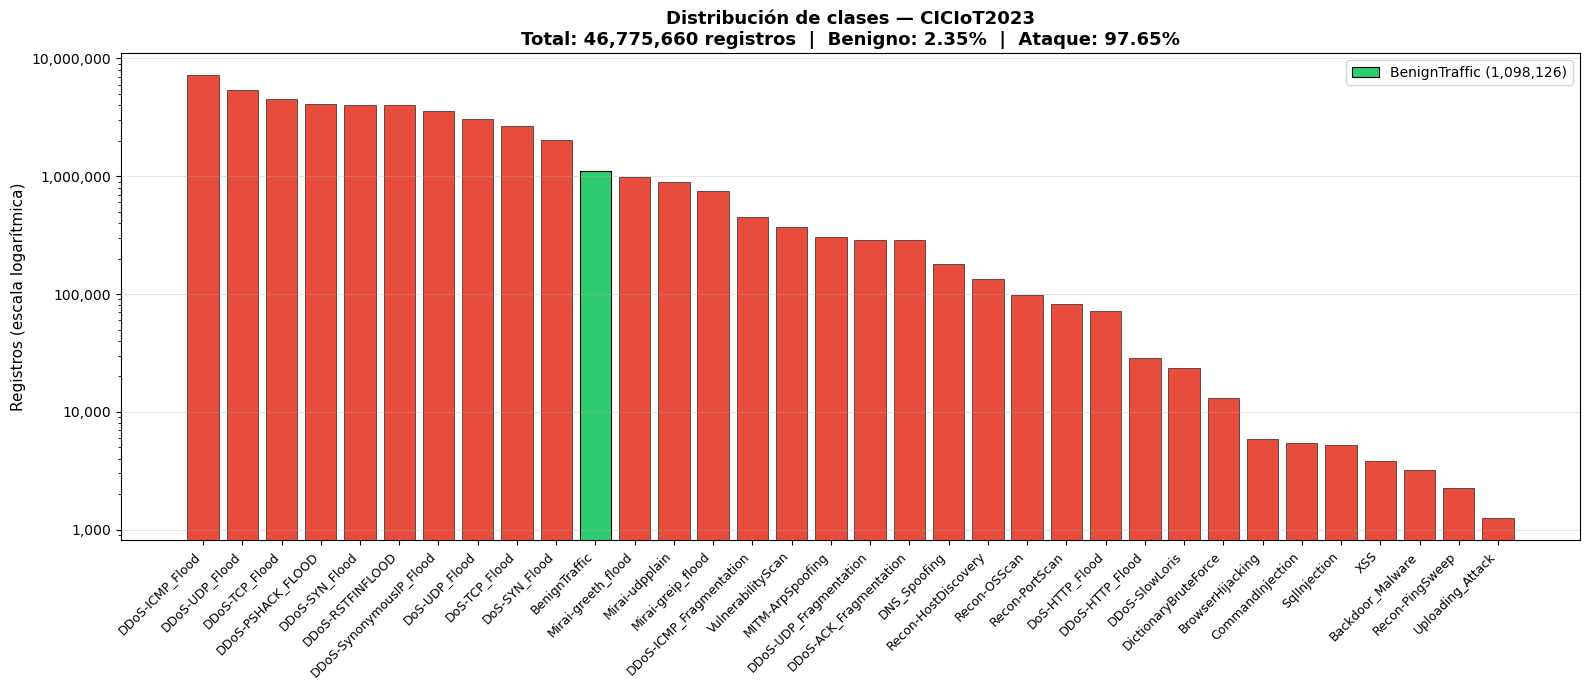

Guardada como distribucion_clases.png


In [10]:
# ── DISTRIBUCIÓN REAL EN DISCO (gráfica) ─────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Reconstruir conteos reales desde conteo_clases
# Si no está en memoria, usar los valores que imprimió el script
conteos = {
    'BenignTraffic':            1098126,
    'DDoS-ICMP_Flood':          7200436,
    'DDoS-UDP_Flood':           5412169,
    'DDoS-TCP_Flood':           4497546,
    'DDoS-PSHACK_FLOOD':        4094727,
    'DDoS-SYN_Flood':           4059097,
    'DDoS-RSTFINFLOOD':         4045248,
    'DDoS-SynonymousIP_Flood':  3598100,
    'DoS-UDP_Flood':            3072883,
    'DoS-TCP_Flood':            2671363,
    'DoS-SYN_Flood':            2028791,
    'Mirai-greeth_flood':        991774,
    'Mirai-udpplain':            890507,
    'Mirai-greip_flood':         751589,
    'DDoS-ICMP_Fragmentation':   452444,
    'MITM-ArpSpoofing':          307542,
    'DDoS-UDP_Fragmentation':    286895,
    'DDoS-ACK_Fragmentation':    285045,
    'VulnerabilityScan':         373344,
    'DNS_Spoofing':              178893,
    'Recon-HostDiscovery':       134377,
    'Recon-OSScan':               98255,
    'Recon-PortScan':             82283,
    'DoS-HTTP_Flood':             71857,
    'DDoS-SlowLoris':             23425,
    'DDoS-HTTP_Flood':            28790,
    'DictionaryBruteForce':       13064,
    'BrowserHijacking':            5859,
    'CommandInjection':            5409,
    'SqlInjection':                5244,
    'XSS':                         3846,
    'Backdoor_Malware':            3218,
    'Recon-PingSweep':             2262,
    'Uploading_Attack':            1252,
}

series  = pd.Series(conteos).sort_values(ascending=False)
total   = series.sum()
colores = ['#2ecc71' if k == 'BenignTraffic'
           else '#e74c3c' for k in series.index]

fig, ax = plt.subplots(figsize=(16, 7))
bars = ax.bar(range(len(series)), series.values,
              color=colores, edgecolor='black', linewidth=0.4)

ax.set_yscale('log')
ax.set_xticks(range(len(series)))
ax.set_xticklabels(series.index, rotation=45,
                   ha='right', fontsize=9)
ax.set_title('Distribución de clases — CICIoT2023\n'
             f'Total: {total:,} registros  |  '
             f'Benigno: 2.35%  |  Ataque: 97.65%',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Registros (escala logarítmica)', fontsize=11)

# Etiqueta en la barra benigna
benigno_idx = list(series.index).index('BenignTraffic')
ax.bar(benigno_idx, series['BenignTraffic'],
       color='#2ecc71', edgecolor='black', linewidth=0.8,
       label=f"BenignTraffic ({series['BenignTraffic']:,})")

ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardada como distribucion_clases.png")

In [11]:
# ── CÓMO ESTÁN REPARTIDOS EN LA DIVISIÓN 70/15/15 ───────────────
import pandas as pd

total_benign = len(X_benign)
n_train      = len(X_train)
n_val        = len(X_val)
n_test       = len(X_test_benign)
n_atk        = len(X_atk)
n_eval       = n_test + n_atk

print("=" * 60)
print("  DISTRIBUCIÓN COMPLETA DEL EXPERIMENTO")
print("=" * 60)

print(f"\n── FASE ENTRENAMIENTO (solo benigno) ──")
print(f"  Train  (70%): {n_train:>10,}  ventanas → {n_train-9:,}")
print(f"  Val    (15%): {n_val:>10,}  ventanas → {n_val-9:,}")
print(f"  (ambos solo tráfico normal — el modelo NUNCA ve ataques)")

print(f"\n── FASE EVALUACIÓN (benigno + ataques) ──")
print(f"  Test benigno: {n_test:>10,}  registros  (para medir FPR)")
print(f"  Ataques:      {n_atk:>10,}  registros  (para medir detección)")
print(f"  TOTAL eval:   {n_eval:>10,}  registros")

print(f"\n── PROPORCIÓN EN EVALUACIÓN ──")
print(f"  Benigno: {n_test/n_eval*100:.1f}%  ({n_test:,})")
print(f"  Ataque:  {n_atk/n_eval*100:.1f}%  ({n_atk:,})")

print(f"\n── ATAQUES EN EVALUACIÓN POR TIPO ──")
etiq, cnts = np.unique(y_atk, return_counts=True)
df_eval = pd.DataFrame({'Tipo': etiq, 'Muestras': cnts})
df_eval = df_eval.sort_values('Muestras', ascending=False)
print(df_eval.to_string(index=False))

print(f"\n── RESUMEN FINAL ──")
print(f"  Total benigno en disco:  {total_benign:,}")
print(f"  Usado para entrenar:     {n_train:,}  (70%)")
print(f"  Usado para umbral θ:     {n_val:,}  (15%)")
print(f"  Usado para eval FPR:     {n_test:,}  (15%)")
print(f"  Ataques para eval det.:  {n_atk:,}  (~2000/tipo)")
print("=" * 60)

  DISTRIBUCIÓN COMPLETA DEL EXPERIMENTO

── FASE ENTRENAMIENTO (solo benigno) ──
  Train  (70%):    768,688  ventanas → 768,679
  Val    (15%):    164,719  ventanas → 164,710
  (ambos solo tráfico normal — el modelo NUNCA ve ataques)

── FASE EVALUACIÓN (benigno + ataques) ──
  Test benigno:    164,719  registros  (para medir FPR)
  Ataques:          65,252  registros  (para medir detección)
  TOTAL eval:      229,971  registros

── PROPORCIÓN EN EVALUACIÓN ──
  Benigno: 71.6%  (164,719)
  Ataque:  28.4%  (65,252)

── ATAQUES EN EVALUACIÓN POR TIPO ──
                   Tipo  Muestras
       Backdoor_Malware      2000
       BrowserHijacking      2000
      VulnerabilityScan      2000
           SqlInjection      2000
         Recon-PortScan      2000
        Recon-PingSweep      2000
           Recon-OSScan      2000
    Recon-HostDiscovery      2000
         Mirai-udpplain      2000
      Mirai-greip_flood      2000
     Mirai-greeth_flood      2000
       MITM-ArpSpoofing      2000


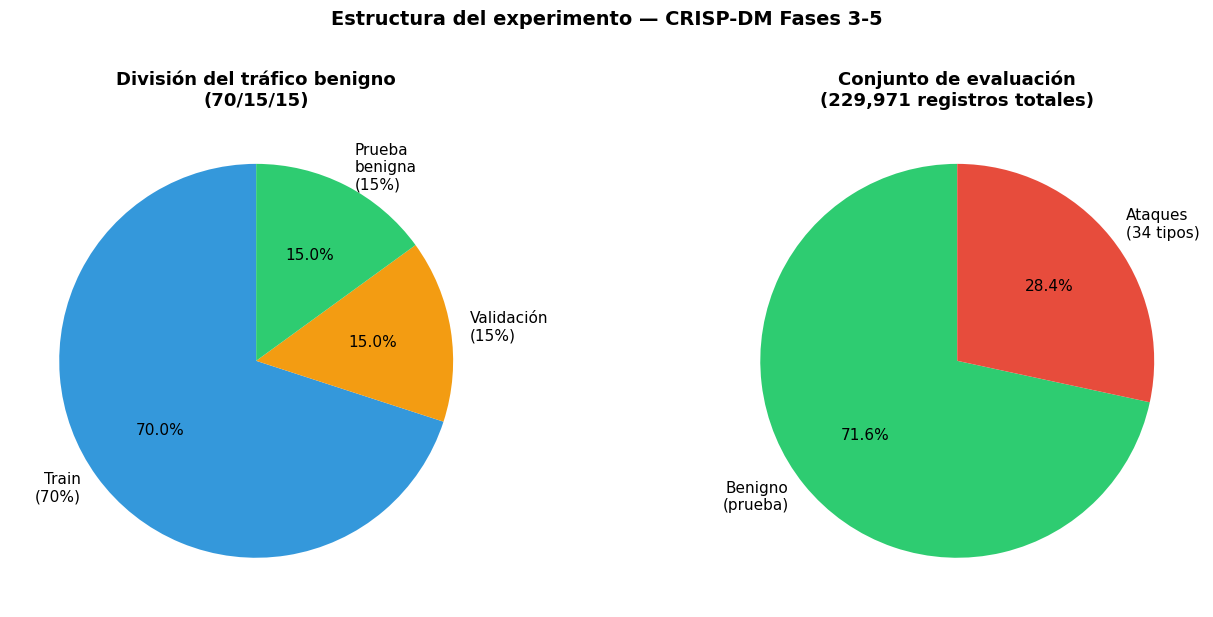

Guardada como division_datos.png


In [12]:
# ── GRÁFICA DE LA DIVISIÓN ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Izquierda — División del benigno
labels_div  = ['Train\n(70%)', 'Validación\n(15%)', 'Prueba\nbenigna\n(15%)']
sizes_div   = [n_train, n_val, n_test]
colores_div = ['#3498db', '#f39c12', '#2ecc71']

axes[0].pie(sizes_div, labels=labels_div,
            colors=colores_div, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[0].set_title('División del tráfico benigno\n(70/15/15)',
                  fontsize=13, fontweight='bold')

# Derecha — Conjunto de evaluación
labels_eval  = ['Benigno\n(prueba)', 'Ataques\n(34 tipos)']
sizes_eval   = [n_test, n_atk]
colores_eval = ['#2ecc71', '#e74c3c']

axes[1].pie(sizes_eval, labels=labels_eval,
            colors=colores_eval, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title(f'Conjunto de evaluación\n'
                  f'({n_eval:,} registros totales)',
                  fontsize=13, fontweight='bold')

plt.suptitle('Estructura del experimento — CRISP-DM Fases 3-5',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('division_datos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardada como division_datos.png")

In [13]:
# ── EXPLORACIÓN DE FEATURES ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Recuperar nombres de columnas del primer CSV benigno
RUTA_CSV = r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz\CSV\CSV"
primer_csv = os.path.join(RUTA_CSV, "Benign_Final", "BenignTraffic.pcap.csv")
df_muestra = pd.read_csv(primer_csv, nrows=5)

feature_names = df_muestra.columns.tolist()
print(f"Total features: {len(feature_names)}")
print(f"\nLista completa:")
for i, f in enumerate(feature_names, 1):
    print(f"  {i:02d}. {f}")

Total features: 39

Lista completa:
  01. Header_Length
  02. Protocol Type
  03. Time_To_Live
  04. Rate
  05. fin_flag_number
  06. syn_flag_number
  07. rst_flag_number
  08. psh_flag_number
  09. ack_flag_number
  10. ece_flag_number
  11. cwr_flag_number
  12. ack_count
  13. syn_count
  14. fin_count
  15. rst_count
  16. HTTP
  17. HTTPS
  18. DNS
  19. Telnet
  20. SMTP
  21. SSH
  22. IRC
  23. TCP
  24. UDP
  25. DHCP
  26. ARP
  27. ICMP
  28. IGMP
  29. IPv
  30. LLC
  31. Tot sum
  32. Min
  33. Max
  34. AVG
  35. Std
  36. Tot size
  37. IAT
  38. Number
  39. Variance


In [14]:
# ── ESTADÍSTICAS DE CADA FEATURE (sobre el benigno) ─────────────
# Usar X_train_scaled que ya está en memoria

stats = pd.DataFrame({
    'Feature':  feature_names,
    'Min':      X_train_scaled.min(axis=0),
    'Max':      X_train_scaled.max(axis=0),
    'Media':    X_train_scaled.mean(axis=0),
    'Std':      X_train_scaled.std(axis=0),
    'Mediana':  np.median(X_train_scaled, axis=0),
})

print("Estadísticas del tráfico benigno (normalizado 0-1):\n")
print(stats.to_string(index=False))

Estadísticas del tráfico benigno (normalizado 0-1):

        Feature  Min  Max    Media      Std  Mediana
  Header_Length  0.0  1.0 0.454218 0.106348 0.493333
  Protocol Type  0.0  1.0 0.406292 0.178463 0.352941
   Time_To_Live  0.0  1.0 0.450931 0.200999 0.387843
           Rate  0.0  1.0 0.000924 0.009127 0.000054
fin_flag_number  0.0  1.0 0.012217 0.040745 0.000000
syn_flag_number  0.0  1.0 0.013799 0.040498 0.000000
rst_flag_number  0.0  1.0 0.001976 0.019770 0.000000
psh_flag_number  0.0  1.0 0.162355 0.152911 0.100000
ack_flag_number  0.0  1.0 0.804879 0.232636 0.900000
ece_flag_number  0.0  1.0 0.001316 0.023040 0.000000
cwr_flag_number  0.0  1.0 0.001128 0.023847 0.000000
      ack_count  0.0  1.0 0.804671 0.233304 0.900000
      syn_count  0.0  1.0 0.013798 0.040494 0.000000
      fin_count  0.0  1.0 0.012216 0.040740 0.000000
      rst_count  0.0  1.0 0.001976 0.019766 0.000000
           HTTP  0.0  1.0 0.058126 0.196663 0.000000
          HTTPS  0.0  1.0 0.693320 0.308509 0.

In [24]:
# ── EXPORTAR PARTICIÓN A CSV ─────────────────────────────────────
import numpy as np
import pandas as pd
import os

SALIDA = r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz"

# Recuperar nombres de features
feature_names = [
    'Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
    'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
    'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
    'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count',
    'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP',
    'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP',
    'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std',
    'Tot size', 'IAT', 'Number', 'Variance'
]

print("Generando CSVs de la partición...\n")

# ── TRAIN (70% benigno) ──────────────────────────────────────────
df_train = pd.DataFrame(X_train_scaled, columns=feature_names)
df_train['label']      = 'BenignTraffic'
df_train['particion']  = 'train'
ruta_train = os.path.join(SALIDA, 'partition_train.csv')
df_train.to_csv(ruta_train, index=False)
print(f"✅ partition_train.csv     {len(df_train):,} registros  "
      f"({len(df_train)/len(X_benign)*100:.1f}%)")
del df_train

# ── VALIDACIÓN (15% benigno) ─────────────────────────────────────
df_val = pd.DataFrame(X_val_scaled, columns=feature_names)
df_val['label']     = 'BenignTraffic'
df_val['particion'] = 'validacion'
ruta_val = os.path.join(SALIDA, 'partition_val.csv')
df_val.to_csv(ruta_val, index=False)
print(f"✅ partition_val.csv       {len(df_val):,} registros  "
      f"({len(df_val)/len(X_benign)*100:.1f}%)")
del df_val

# ── TEST BENIGNO (15% benigno) ───────────────────────────────────
df_test = pd.DataFrame(X_test_scaled, columns=feature_names)
df_test['label']     = 'BenignTraffic'
df_test['particion'] = 'test_benigno'
ruta_test = os.path.join(SALIDA, 'partition_test_benign.csv')
df_test.to_csv(ruta_test, index=False)
print(f"✅ partition_test_benign.csv {len(df_test):,} registros  "
      f"({len(df_test)/len(X_benign)*100:.1f}%)")
del df_test

# ── ATAQUES (muestreo estratificado) ────────────────────────────
df_atk_export = pd.DataFrame(X_atk_scaled, columns=feature_names)
df_atk_export['label']     = y_atk
df_atk_export['particion'] = 'evaluacion_ataque'
ruta_atk = os.path.join(SALIDA, 'partition_attacks.csv')
df_atk_export.to_csv(ruta_atk, index=False)
print(f"✅ partition_attacks.csv   {len(df_atk_export):,} registros  "
      f"({len(df_atk_export['label'].unique())} tipos)")
del df_atk_export

# ── CSV DE RESUMEN ───────────────────────────────────────────────
total_benign = len(X_benign)
n_train      = len(X_train_scaled)
n_val        = len(X_val_scaled)
n_test       = len(X_test_scaled)
n_atk        = len(X_atk_scaled)

resumen = pd.DataFrame([
    {
        'particion':        'train',
        'tipo':             'benigno',
        'registros':        n_train,
        'porcentaje_total': round(n_train / total_benign * 100, 2),
        'uso':              'Entrenar pesos LSTM-AE',
        'archivo':          'partition_train.csv'
    },
    {
        'particion':        'validacion',
        'tipo':             'benigno',
        'registros':        n_val,
        'porcentaje_total': round(n_val / total_benign * 100, 2),
        'uso':              'Calibrar umbral theta = mu + k*sigma',
        'archivo':          'partition_val.csv'
    },
    {
        'particion':        'test_benigno',
        'tipo':             'benigno',
        'registros':        n_test,
        'porcentaje_total': round(n_test / total_benign * 100, 2),
        'uso':              'Medir FPR en evaluacion final',
        'archivo':          'partition_test_benign.csv'
    },
    {
        'particion':        'evaluacion_ataque',
        'tipo':             'ataque',
        'registros':        n_atk,
        'porcentaje_total': round(n_atk / total_benign * 100, 2),
        'uso':              'Medir deteccion (F1, Recall, Precision)',
        'archivo':          'partition_attacks.csv'
    },
])

ruta_resumen = os.path.join(SALIDA, 'partition_resumen.csv')
resumen.to_csv(ruta_resumen, index=False)

print(f"\n✅ partition_resumen.csv  (tabla resumen)\n")
print(resumen.to_string(index=False))

# ── RESUMEN POR TIPO DE ATAQUE ───────────────────────────────────
etiq, cnts = np.unique(y_atk, return_counts=True)
df_atk_resumen = pd.DataFrame({
    'tipo_ataque': etiq,
    'muestras':    cnts,
    'particion':   'evaluacion_ataque'
}).sort_values('muestras', ascending=False)

ruta_atk_det = os.path.join(SALIDA, 'partition_attacks_detalle.csv')
df_atk_resumen.to_csv(ruta_atk_det, index=False)
print(f"\n✅ partition_attacks_detalle.csv")
print(df_atk_resumen.to_string(index=False))

print(f"\n{'='*55}")
print(f"Archivos generados en:")
print(f"  {SALIDA}")
print(f"{'='*55}")
print(f"  partition_train.csv              {n_train:,} reg.")
print(f"  partition_val.csv                {n_val:,} reg.")
print(f"  partition_test_benign.csv        {n_test:,} reg.")
print(f"  partition_attacks.csv            {n_atk:,} reg.")
print(f"  partition_resumen.csv            resumen general")
print(f"  partition_attacks_detalle.csv    detalle ataques")

Generando CSVs de la partición...

✅ partition_train.csv     768,688 registros  (70.0%)
✅ partition_val.csv       164,719 registros  (15.0%)
✅ partition_test_benign.csv 164,719 registros  (15.0%)
✅ partition_attacks.csv   65,252 registros  (33 tipos)

✅ partition_resumen.csv  (tabla resumen)

        particion    tipo  registros  porcentaje_total                                     uso                   archivo
            train benigno     768688             70.00                  Entrenar pesos LSTM-AE       partition_train.csv
       validacion benigno     164719             15.00    Calibrar umbral theta = mu + k*sigma         partition_val.csv
     test_benigno benigno     164719             15.00           Medir FPR en evaluacion final partition_test_benign.csv
evaluacion_ataque  ataque      65252              5.94 Medir deteccion (F1, Recall, Precision)     partition_attacks.csv

✅ partition_attacks_detalle.csv
            tipo_ataque  muestras         particion
       Backdoor_

In [23]:
# ── ANÁLISIS CAPA 2 — CICIoT2023 ────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

SALIDA = r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz"

# Índices de features capa 2 (base 0)
# 25 = ARP, 29 = LLC
IDX_ARP = 25
IDX_LLC = 29

feature_names = [
    'Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
    'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
    'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
    'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count',
    'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP',
    'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP',
    'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std',
    'Tot size', 'IAT', 'Number', 'Variance'
]

FEATURES_CAPA2 = {
    'ARP': 25,
    'LLC': 29
}

print("=" * 60)
print("  ANÁLISIS CAPA 2 — CICIoT2023")
print("  ARP (idx=25) y LLC (idx=29)")
print("=" * 60)

  ANÁLISIS CAPA 2 — CICIoT2023
  ARP (idx=25) y LLC (idx=29)


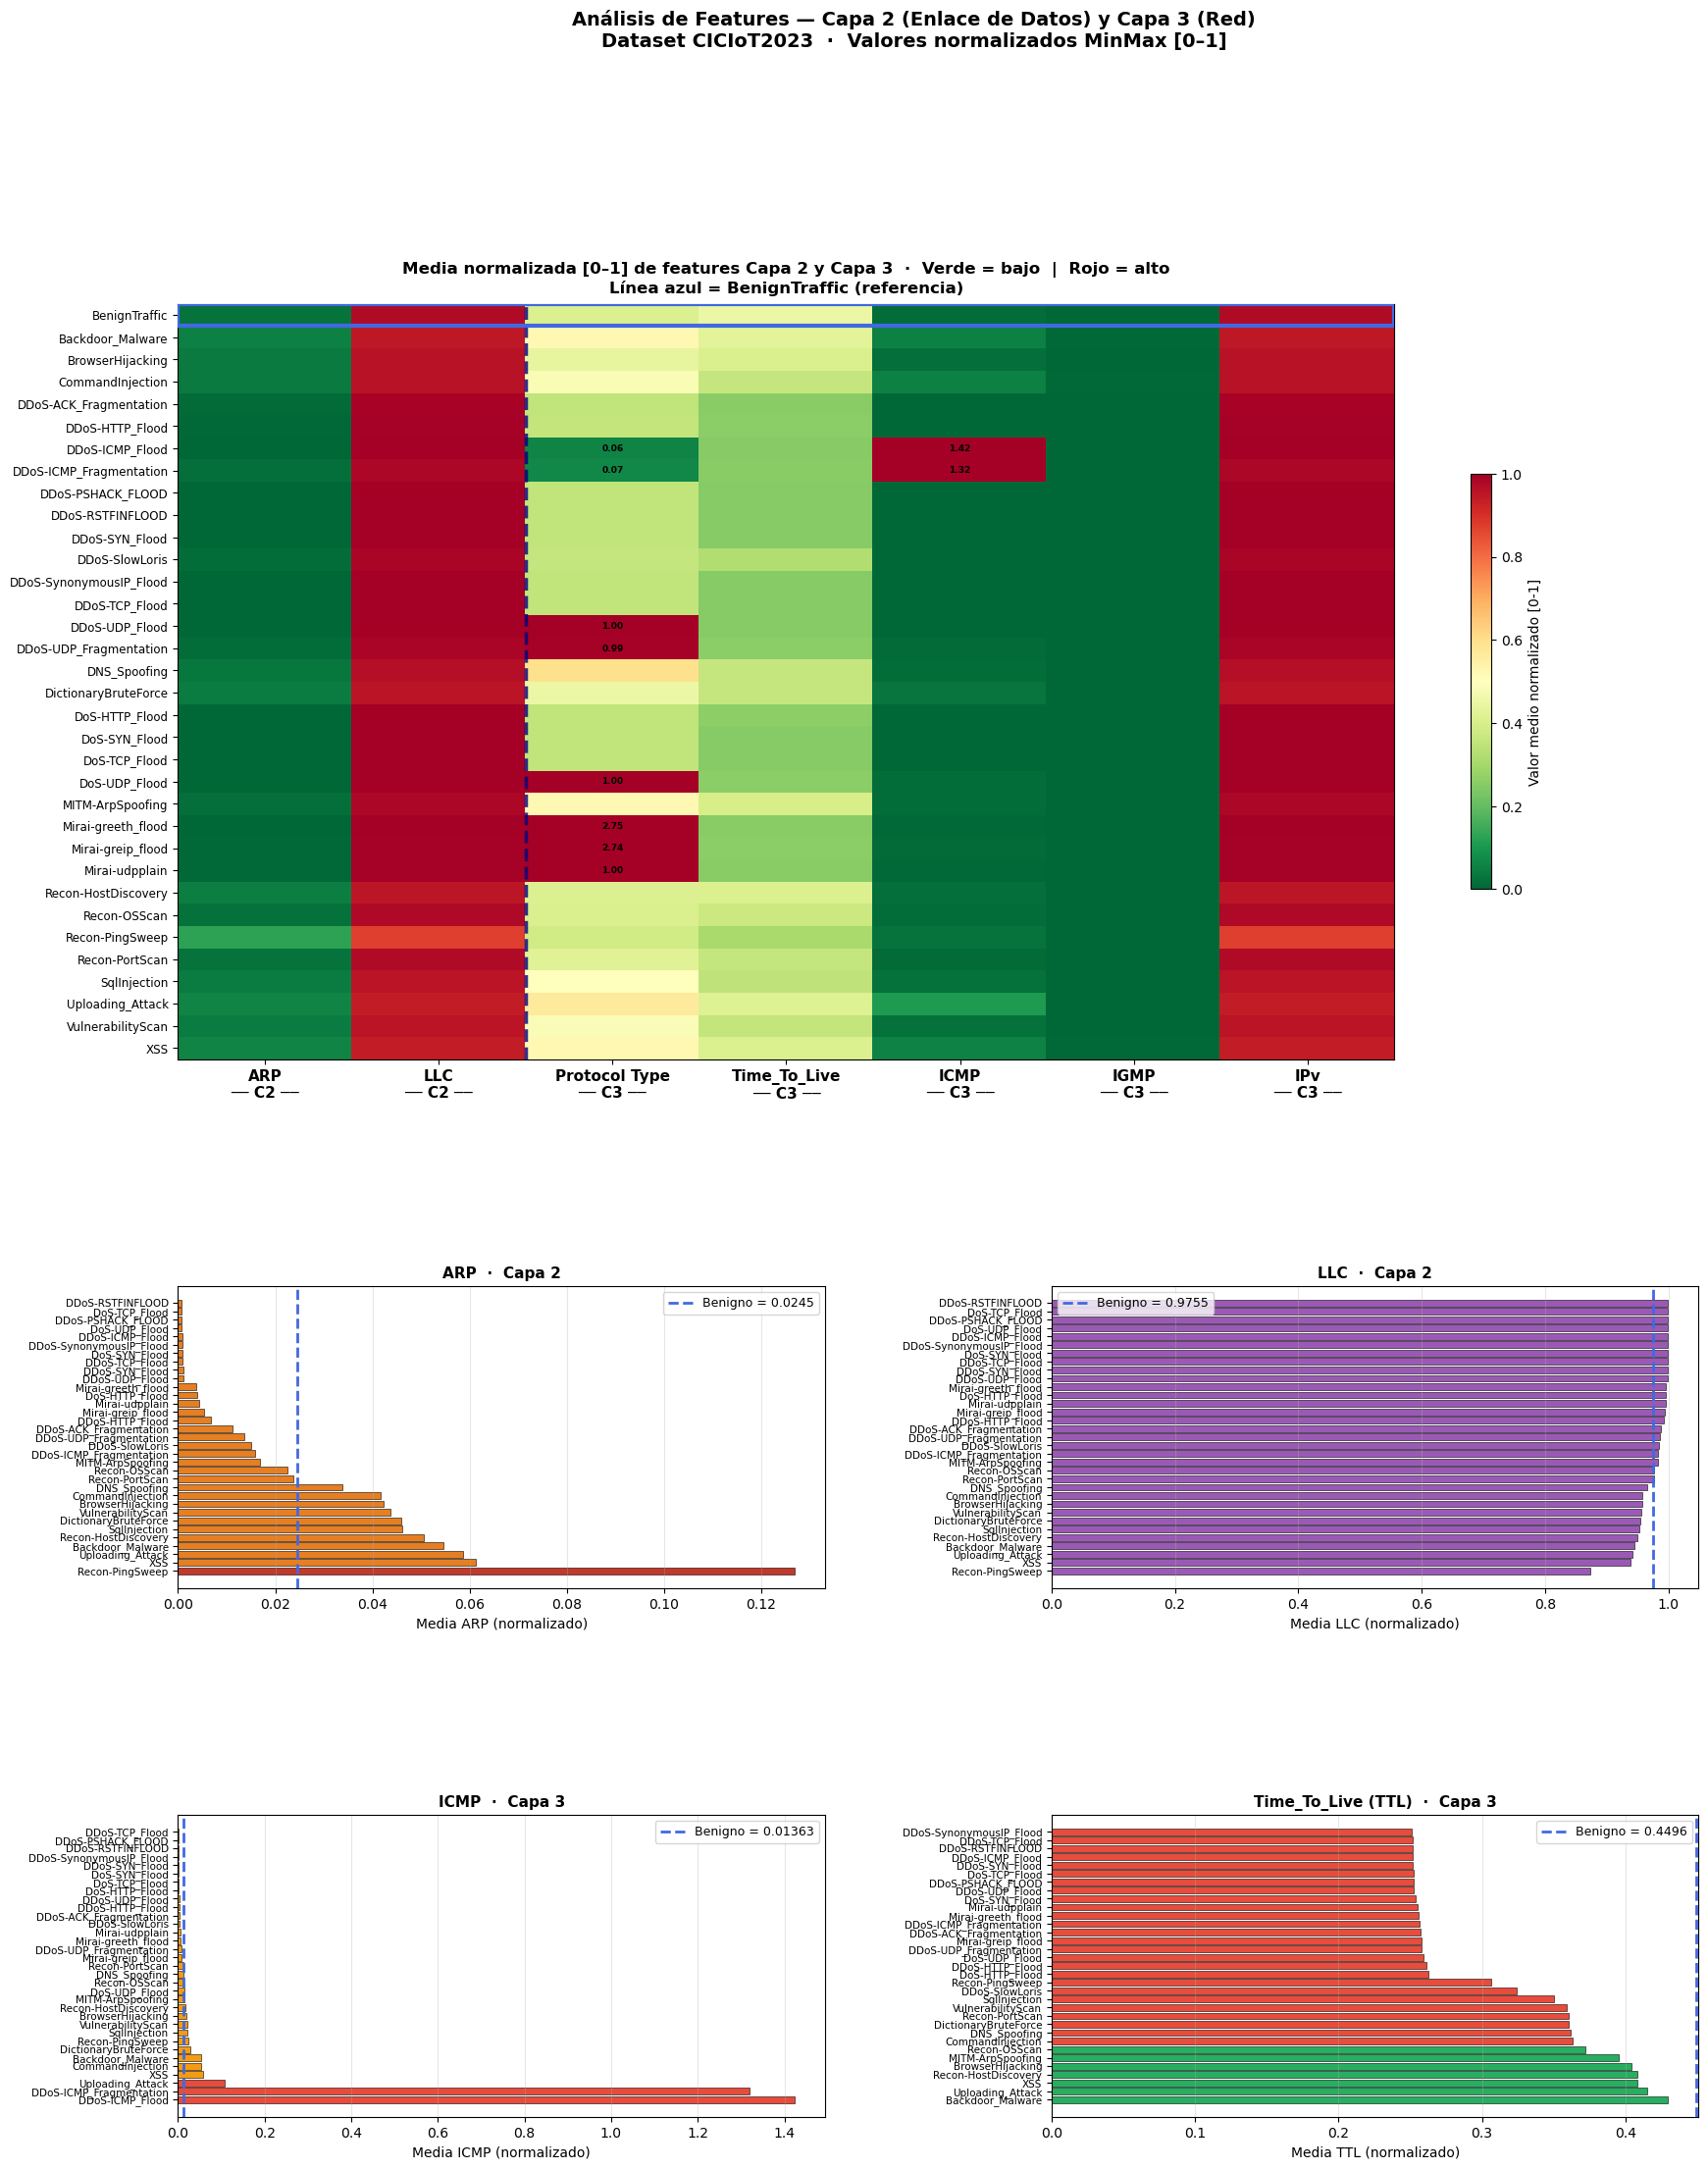

Guardada como analisis_capas_2_3.png

  MEDIAS NORMALIZADAS [0-1] POR CLASE
                            ARP     LLC  Protocol Type  Time_To_Live    ICMP    IGMP     IPv
Clase                                                                                       
BenignTraffic            0.0245  0.9755         0.4066        0.4496  0.0136  0.0008  0.9755
Backdoor_Malware         0.0546  0.9454         0.5234        0.4295  0.0526  0.0043  0.9454
BrowserHijacking         0.0423  0.9577         0.4411        0.4043  0.0184  0.0033  0.9577
CommandInjection         0.0418  0.9582         0.4828        0.3632  0.0535  0.0043  0.9582
DDoS-ACK_Fragmentation   0.0111  0.9889         0.3549        0.2573  0.0030  0.0003  0.9889
DDoS-HTTP_Flood          0.0068  0.9932         0.3559        0.2609  0.0027  0.0007  0.9932
DDoS-ICMP_Flood          0.0009  0.9991         0.0591        0.2517  1.4228  0.0000  0.9991
DDoS-ICMP_Fragmentation  0.0160  0.9840         0.0680        0.2566  1.3199  0.0001  0

In [20]:
# ── VISUALIZACIÓN CAPAS 2 Y 3 POR TIPO DE ATAQUE ────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

feature_names = [
    'Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
    'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
    'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
    'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count',
    'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP',
    'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP',
    'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std',
    'Tot size', 'IAT', 'Number', 'Variance'
]

CAPA2 = {'ARP': 25, 'LLC': 29}
CAPA3 = {'Protocol Type': 1, 'Time_To_Live': 2, 'ICMP': 26, 'IGMP': 27, 'IPv': 28}
FEATS_OSI = {**CAPA2, **CAPA3}

feat_nombres = list(FEATS_OSI.keys())
feat_indices = list(FEATS_OSI.values())

# ── MEDIAS POR CLASE ──────────────────────────────────────────────
np.random.seed(42)
idx_b = np.random.choice(len(X_train_scaled), 5000, replace=False)
benign_sample = X_train_scaled[idx_b]
tipos = np.unique(y_atk)

filas = [{'Clase': 'BenignTraffic',
          **dict(zip(feat_nombres, benign_sample[:, feat_indices].mean(axis=0)))}]
for tipo in tipos:
    mask = y_atk == tipo
    media = X_atk_scaled[mask][:, feat_indices].mean(axis=0)
    filas.append({'Clase': tipo, **dict(zip(feat_nombres, media))})

df_heat = pd.DataFrame(filas).set_index('Clase').astype(float)

# ── FIGURA ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 24))
gs  = gridspec.GridSpec(3, 2, figure=fig,
                        height_ratios=[2.5, 1, 1],
                        hspace=0.5, wspace=0.35)

# GRÁFICA 1 — Heatmap completo (fila superior, ambas columnas)
ax_heat = fig.add_subplot(gs[0, :])

im = ax_heat.imshow(df_heat.values, aspect='auto',
                    cmap='RdYlGn_r', vmin=0, vmax=1)

etiquetas_x = [
    f'{n}\n── C2 ──' if n in CAPA2 else f'{n}\n── C3 ──'
    for n in feat_nombres
]
ax_heat.set_xticks(range(len(feat_nombres)))
ax_heat.set_xticklabels(etiquetas_x, fontsize=11, fontweight='bold')
ax_heat.set_yticks(range(len(df_heat)))
ax_heat.set_yticklabels(df_heat.index, fontsize=8.5)
ax_heat.set_title(
    'Media normalizada [0–1] de features Capa 2 y Capa 3  ·  Verde = bajo  |  Rojo = alto\n'
    'Línea azul = BenignTraffic (referencia)',
    fontsize=12, fontweight='bold', pad=8
)
# Borde azul en fila benigna
ax_heat.add_patch(plt.Rectangle(
    (-0.5, -0.5), len(feat_nombres), 1,
    fill=False, edgecolor='royalblue', linewidth=3, zorder=5
))
# Separador C2 / C3
ax_heat.axvline(x=1.5, color='navy', linewidth=2.5,
                linestyle='--', alpha=0.8)

plt.colorbar(im, ax=ax_heat, shrink=0.55,
             label='Valor medio normalizado [0-1]')

# Anotar valores en celdas si son "extremos" (>0.5 o hay diferencia grande)
benign_vals = df_heat.loc['BenignTraffic'].values
for i, clase in enumerate(df_heat.index):
    for j, val in enumerate(df_heat.iloc[i].values):
        diff = abs(val - benign_vals[j])
        if diff > 0.3:
            ax_heat.text(j, i, f'{val:.2f}', ha='center', va='center',
                        fontsize=6.5, color='black', fontweight='bold')

# GRÁFICA 2 — ARP por ataque
ax_arp = fig.add_subplot(gs[1, 0])
arp_vals  = df_heat['ARP'].drop('BenignTraffic').sort_values(ascending=False)
b_arp     = df_heat.loc['BenignTraffic', 'ARP']
colores   = ['#c0392b' if v > b_arp * 4 else '#e67e22' for v in arp_vals.values]

ax_arp.barh(range(len(arp_vals)), arp_vals.values,
            color=colores, edgecolor='black', linewidth=0.4)
ax_arp.axvline(b_arp, color='royalblue', linestyle='--',
               linewidth=2, label=f'Benigno = {b_arp:.4f}')
ax_arp.set_yticks(range(len(arp_vals)))
ax_arp.set_yticklabels(arp_vals.index, fontsize=7.5)
ax_arp.set_xlabel('Media ARP (normalizado)', fontsize=10)
ax_arp.set_title('ARP  ·  Capa 2', fontsize=11, fontweight='bold')
ax_arp.legend(fontsize=9)
ax_arp.grid(axis='x', alpha=0.3)

# GRÁFICA 3 — LLC por ataque
ax_llc = fig.add_subplot(gs[1, 1])
llc_vals  = df_heat['LLC'].drop('BenignTraffic').sort_values(ascending=True)
b_llc     = df_heat.loc['BenignTraffic', 'LLC']
colores   = ['#8e44ad' if v < b_llc * 0.4 else '#9b59b6' for v in llc_vals.values]

ax_llc.barh(range(len(llc_vals)), llc_vals.values,
            color=colores, edgecolor='black', linewidth=0.4)
ax_llc.axvline(b_llc, color='royalblue', linestyle='--',
               linewidth=2, label=f'Benigno = {b_llc:.4f}')
ax_llc.set_yticks(range(len(llc_vals)))
ax_llc.set_yticklabels(llc_vals.index, fontsize=7.5)
ax_llc.set_xlabel('Media LLC (normalizado)', fontsize=10)
ax_llc.set_title('LLC  ·  Capa 2', fontsize=11, fontweight='bold')
ax_llc.legend(fontsize=9)
ax_llc.grid(axis='x', alpha=0.3)

# GRÁFICA 4 — ICMP por ataque
ax_icmp = fig.add_subplot(gs[2, 0])
icmp_vals = df_heat['ICMP'].drop('BenignTraffic').sort_values(ascending=False)
b_icmp    = df_heat.loc['BenignTraffic', 'ICMP']
colores   = ['#e74c3c' if v > b_icmp * 5 else '#f39c12' for v in icmp_vals.values]

ax_icmp.barh(range(len(icmp_vals)), icmp_vals.values,
             color=colores, edgecolor='black', linewidth=0.4)
ax_icmp.axvline(b_icmp, color='royalblue', linestyle='--',
                linewidth=2, label=f'Benigno = {b_icmp:.5f}')
ax_icmp.set_yticks(range(len(icmp_vals)))
ax_icmp.set_yticklabels(icmp_vals.index, fontsize=7.5)
ax_icmp.set_xlabel('Media ICMP (normalizado)', fontsize=10)
ax_icmp.set_title('ICMP  ·  Capa 3', fontsize=11, fontweight='bold')
ax_icmp.legend(fontsize=9)
ax_icmp.grid(axis='x', alpha=0.3)

# GRÁFICA 5 — TTL por ataque
ax_ttl = fig.add_subplot(gs[2, 1])
ttl_vals  = df_heat['Time_To_Live'].drop('BenignTraffic').sort_values(ascending=False)
b_ttl     = df_heat.loc['BenignTraffic', 'Time_To_Live']
colores   = ['#27ae60' if abs(v - b_ttl) < 0.08 else '#e74c3c' for v in ttl_vals.values]

ax_ttl.barh(range(len(ttl_vals)), ttl_vals.values,
            color=colores, edgecolor='black', linewidth=0.4)
ax_ttl.axvline(b_ttl, color='royalblue', linestyle='--',
               linewidth=2, label=f'Benigno = {b_ttl:.4f}')
ax_ttl.set_yticks(range(len(ttl_vals)))
ax_ttl.set_yticklabels(ttl_vals.index, fontsize=7.5)
ax_ttl.set_xlabel('Media TTL (normalizado)', fontsize=10)
ax_ttl.set_title('Time_To_Live (TTL)  ·  Capa 3', fontsize=11, fontweight='bold')
ax_ttl.legend(fontsize=9)
ax_ttl.grid(axis='x', alpha=0.3)

plt.suptitle(
    'Análisis de Features — Capa 2 (Enlace de Datos) y Capa 3 (Red)\n'
    'Dataset CICIoT2023  ·  Valores normalizados MinMax [0–1]',
    fontsize=14, fontweight='bold', y=1.005
)

plt.savefig('analisis_capas_2_3.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardada como analisis_capas_2_3.png")

# ── TABLA NUMÉRICA ────────────────────────────────────────────────
print("\n" + "="*72)
print("  MEDIAS NORMALIZADAS [0-1] POR CLASE")
print("="*72)
print(df_heat.round(4).to_string())


In [1]:
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split

# ── RUTAS ────────────────────────────────────────────────────────
BASE = r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz"

# ── NOMBRES DE LAS 39 FEATURES ──────────────────────────────────
FEATURES = [
    'Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
    'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
    'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
    'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count',
    'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP',
    'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP',
    'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std',
    'Tot size', 'IAT', 'Number', 'Variance'
]

# ── CARGAR DATOS RAW ─────────────────────────────────────────────
X_benign = np.load(BASE + r'\benign_raw.npy')        # (1_098_126, 39)
X_atk    = np.load(BASE + r'\atk_raw.npy')           # (65_252,    39)
y_atk    = np.load(BASE + r'\atk_labels.npy', allow_pickle=True)  # (65_252,)
scaler   = joblib.load(BASE + r'\scaler.pkl')

# ── SPLITS 70/15/15 (misma seed que en analisis_de_datos.ipynb) ──
X_train, X_temp = train_test_split(X_benign, test_size=0.30, random_state=42)
X_val, X_test   = train_test_split(X_temp,   test_size=0.50, random_state=42)
del X_temp

# ── NORMALIZAR ────────────────────────────────────────────────────
X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)
X_atk_s   = scaler.transform(X_atk)

# ── RESUMEN ───────────────────────────────────────────────────────
print(f"Features:          {len(FEATURES)}")
print(f"Train  (70%):      {X_train_s.shape}")
print(f"Val    (15%):      {X_val_s.shape}")
print(f"Test   (15%):      {X_test_s.shape}")
print(f"Ataques (eval):    {X_atk_s.shape}  —  {len(np.unique(y_atk))} tipos")
print(f"\nTipos de ataque:\n{np.unique(y_atk)}")


Features:          39
Train  (70%):      (768688, 39)
Val    (15%):      (164719, 39)
Test   (15%):      (164719, 39)
Ataques (eval):    (65252, 39)  —  33 tipos

Tipos de ataque:
['Backdoor_Malware' 'BrowserHijacking' 'CommandInjection'
 'DDoS-ACK_Fragmentation' 'DDoS-HTTP_Flood' 'DDoS-ICMP_Flood'
 'DDoS-ICMP_Fragmentation' 'DDoS-PSHACK_FLOOD' 'DDoS-RSTFINFLOOD'
 'DDoS-SYN_Flood' 'DDoS-SlowLoris' 'DDoS-SynonymousIP_Flood'
 'DDoS-TCP_Flood' 'DDoS-UDP_Flood' 'DDoS-UDP_Fragmentation' 'DNS_Spoofing'
 'DictionaryBruteForce' 'DoS-HTTP_Flood' 'DoS-SYN_Flood' 'DoS-TCP_Flood'
 'DoS-UDP_Flood' 'MITM-ArpSpoofing' 'Mirai-greeth_flood'
 'Mirai-greip_flood' 'Mirai-udpplain' 'Recon-HostDiscovery' 'Recon-OSScan'
 'Recon-PingSweep' 'Recon-PortScan' 'SqlInjection' 'Uploading_Attack'
 'VulnerabilityScan' 'XSS']


Features:   39
Train:      (768688, 39)
Val:        (164719, 39)
Test:       (164719, 39)
Ataques:    (65252, 39)  —  33 tipos

  FEATURE                GRUPO                      Media_B   Std_B  Media_A   Std_A      Δ

  ── Capa 2 — Enlace ──
  ARP                    Capa 2 — Enlace             0.0242  0.0611   0.0225  0.0737 -0.002
  LLC                    Capa 2 — Enlace             0.9758  0.0611   0.9775  0.0737 +0.002

  ── Capa 3 — Red ──
  Protocol Type          Capa 3 — Red                0.0239  0.0105   0.0361  0.0362 +0.012
  Time_To_Live           Capa 3 — Red                0.0018  0.0008   0.0012  0.0005 -0.001
  ICMP                   Capa 3 — Red                0.0172  0.0662   0.1408  0.4753 +0.124 ◀
  IGMP                   Capa 3 — Red                0.0075  0.1395   0.0060  0.1280 -0.002
  IPv                    Capa 3 — Red                0.9758  0.0611   0.9775  0.0737 +0.002

  ── Capa 4 — Transporte ──
  TCP                    Capa 4 — Transporte         0.814

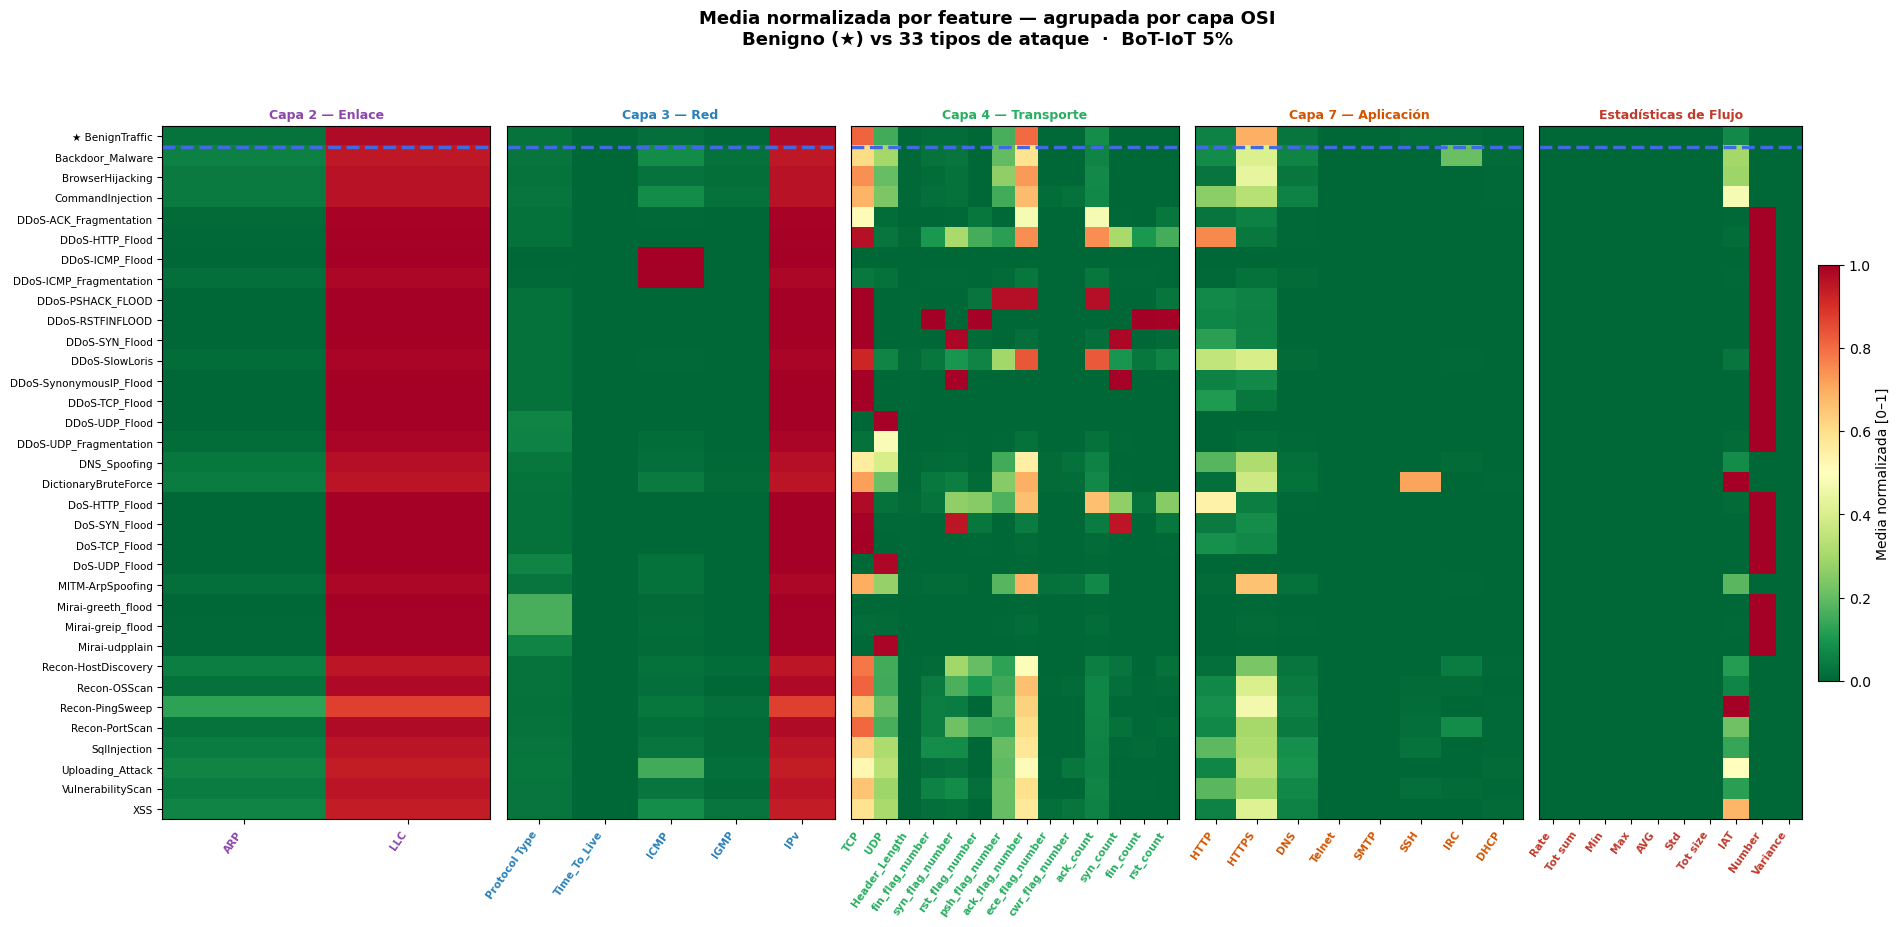

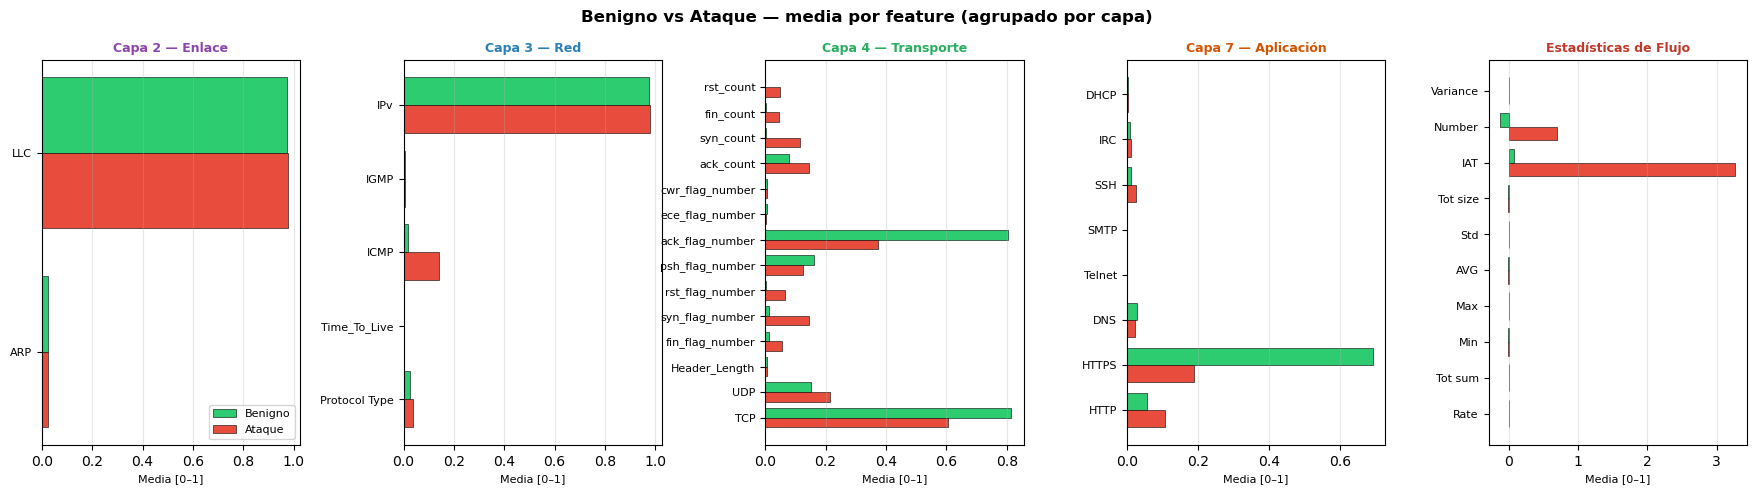

Guardado: features_por_grupo.png  |  features_comparacion.png


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# ── CARGAR DIRECTAMENTE DESDE LOS CSVs YA PARTICIONADOS ──────────
BASE = r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz"

df_train = pd.read_csv(BASE + r'\partition_train.csv')
df_val   = pd.read_csv(BASE + r'\partition_val.csv')
df_test  = pd.read_csv(BASE + r'\partition_test_benign.csv')
df_atk   = pd.read_csv(BASE + r'\partition_attacks.csv')

FEATURES = [c for c in df_train.columns if c not in ('label', 'particion')]

# ── NORMALIZAR CON EL SCALER YA ENTRENADO ────────────────────────
scaler    = joblib.load(BASE + r'\scaler.pkl')

X_train_s = scaler.transform(df_train[FEATURES].values)
X_val_s   = scaler.transform(df_val[FEATURES].values)
X_test_s  = scaler.transform(df_test[FEATURES].values)
X_atk_s   = scaler.transform(df_atk[FEATURES].values)
y_atk     = df_atk['label'].values

print(f"Features:   {len(FEATURES)}")
print(f"Train:      {X_train_s.shape}")
print(f"Val:        {X_val_s.shape}")
print(f"Test:       {X_test_s.shape}")
print(f"Ataques:    {X_atk_s.shape}  —  {len(np.unique(y_atk))} tipos")

# ── GRUPOS POR CAPA OSI ───────────────────────────────────────────
GRUPOS = {
    'Capa 2 — Enlace':       ['ARP', 'LLC'],
    'Capa 3 — Red':          ['Protocol Type', 'Time_To_Live', 'ICMP', 'IGMP', 'IPv'],
    'Capa 4 — Transporte':   ['TCP', 'UDP', 'Header_Length',
                              'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
                              'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
                              'cwr_flag_number', 'ack_count', 'syn_count',
                              'fin_count', 'rst_count'],
    'Capa 7 — Aplicación':   ['HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP',
                              'SSH', 'IRC', 'DHCP'],
    'Estadísticas de Flujo': ['Rate', 'Tot sum', 'Min', 'Max', 'AVG',
                              'Std', 'Tot size', 'IAT', 'Number', 'Variance'],
}

COLORES_GRUPO = {
    'Capa 2 — Enlace':       '#8e44ad',
    'Capa 3 — Red':          '#2980b9',
    'Capa 4 — Transporte':   '#27ae60',
    'Capa 7 — Aplicación':   '#d35400',
    'Estadísticas de Flujo': '#c0392b',
}

f2i = {f: i for i, f in enumerate(FEATURES)}

# ── 1. TABLA: ESTADÍSTICAS POR GRUPO ─────────────────────────────
print("\n" + "=" * 85)
print(f"  {'FEATURE':<22} {'GRUPO':<25} {'Media_B':>8} {'Std_B':>7} {'Media_A':>8} {'Std_A':>7} {'Δ':>6}")
print("=" * 85)

for grupo, feats in GRUPOS.items():
    print(f"\n  ── {grupo} ──")
    for f in feats:
        idx   = f2i[f]
        mb    = X_train_s[:, idx].mean()
        sb    = X_train_s[:, idx].std()
        ma    = X_atk_s[:,   idx].mean()
        sa    = X_atk_s[:,   idx].std()
        delta = ma - mb
        marca = " ◀" if abs(delta) > 0.10 else ""
        print(f"  {f:<22} {grupo:<25} {mb:>8.4f} {sb:>7.4f} {ma:>8.4f} {sa:>7.4f} {delta:>+6.3f}{marca}")

print("\n  ◀ = diferencia > 0.10 entre benigno (train) y ataques")

# ── 2. HEATMAP POR CAPA ───────────────────────────────────────────
tipos  = np.unique(y_atk)
clases = ['★ BenignTraffic'] + list(tipos)

fig, axes = plt.subplots(1, len(GRUPOS), figsize=(22, 9),
                         gridspec_kw={'wspace': 0.05})

for ax, (grupo, feats) in zip(axes, GRUPOS.items()):
    indices = [f2i[f] for f in feats]
    color   = COLORES_GRUPO[grupo]

    matriz = [X_train_s[:, indices].mean(axis=0)]
    for tipo in tipos:
        mask = y_atk == tipo
        matriz.append(X_atk_s[mask][:, indices].mean(axis=0))

    M  = np.array(matriz)
    im = ax.imshow(M, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)

    ax.set_xticks(range(len(feats)))
    ax.set_xticklabels(feats, rotation=55, ha='right',
                       fontsize=7.5, color=color, fontweight='bold')
    ax.axhline(0.5, color='royalblue', linewidth=2.5, linestyle='--')
    ax.set_title(grupo, fontsize=9, fontweight='bold', color=color, pad=6)

    if ax == axes[0]:
        ax.set_yticks(range(len(clases)))
        ax.set_yticklabels(clases, fontsize=7.5)
    else:
        ax.set_yticks([])

plt.colorbar(im, ax=axes[-1], shrink=0.6, label='Media normalizada [0–1]')
plt.suptitle(
    'Media normalizada por feature — agrupada por capa OSI\n'
    'Benigno (★) vs 33 tipos de ataque  ·  BoT-IoT 5%',
    fontsize=13, fontweight='bold', y=1.01
)
plt.savefig(BASE + r'\features_por_grupo.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 3. BARRAS: BENIGNO vs ATAQUE POR GRUPO ───────────────────────
fig, axes = plt.subplots(1, len(GRUPOS), figsize=(22, 5),
                         gridspec_kw={'wspace': 0.4})

for ax, (grupo, feats) in zip(axes, GRUPOS.items()):
    indices = [f2i[f] for f in feats]
    color   = COLORES_GRUPO[grupo]
    mb      = X_train_s[:, indices].mean(axis=0)
    ma      = X_atk_s[:,   indices].mean(axis=0)

    x, w = np.arange(len(feats)), 0.38
    ax.barh(x + w/2, mb, w, label='Benigno', color='#2ecc71',
            edgecolor='black', linewidth=0.4)
    ax.barh(x - w/2, ma, w, label='Ataque',  color='#e74c3c',
            edgecolor='black', linewidth=0.4)

    ax.set_yticks(x)
    ax.set_yticklabels(feats, fontsize=8)
    ax.set_xlabel('Media [0–1]', fontsize=8)
    ax.set_title(grupo, fontsize=9, fontweight='bold', color=color)
    ax.grid(axis='x', alpha=0.3)
    if ax == axes[0]:
        ax.legend(fontsize=8)

plt.suptitle('Benigno vs Ataque — media por feature (agrupado por capa)',
             fontsize=12, fontweight='bold')
plt.savefig(BASE + r'\features_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

print("Guardado: features_por_grupo.png  |  features_comparacion.png")

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

BASE = r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz"

df_train = pd.read_csv(BASE + r'\partition_train.csv')
df_val   = pd.read_csv(BASE + r'\partition_val.csv')
df_test  = pd.read_csv(BASE + r'\partition_test_benign.csv')
df_atk   = pd.read_csv(BASE + r'\partition_attacks.csv')

# ── ORDEN EXACTO CON EL QUE SE ENTRENÓ EL SCALER ─────────────────
FEATURES = [
    'Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
    'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
    'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
    'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count',
    'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP',
    'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP',
    'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std',
    'Tot size', 'IAT', 'Number', 'Variance'
]

scaler = joblib.load(BASE + r'\scaler.pkl')

# Al pasar FEATURES explícito, pandas reordena las columnas automáticamente
X_train_s = scaler.transform(df_train[FEATURES].values)
X_val_s   = scaler.transform(df_val[FEATURES].values)
X_test_s  = scaler.transform(df_test[FEATURES].values)
X_atk_s   = scaler.transform(df_atk[FEATURES].values)
y_atk     = df_atk['label'].values

# ── VERIFICACIÓN RÁPIDA ───────────────────────────────────────────
print(f"Features:   {len(FEATURES)}")
print(f"Train:      {X_train_s.shape}")
print(f"Val:        {X_val_s.shape}")
print(f"Test:       {X_test_s.shape}")
print(f"Ataques:    {X_atk_s.shape}  —  {len(np.unique(y_atk))} tipos")

# Sanidad: el train benigno debe tener todas las medias entre 0 y 1
medias_train = X_train_s.mean(axis=0)
negativos    = (medias_train < 0).sum()
mayores_a_1  = (medias_train > 1).sum()
print(f"\n✅ Sanity check train — negativos: {negativos}  |  >1: {mayores_a_1}")
print("   (ambos deben ser 0 si el scaler está bien aplicado)")

Features:   39
Train:      (768688, 39)
Val:        (164719, 39)
Test:       (164719, 39)
Ataques:    (65252, 39)  —  33 tipos

✅ Sanity check train — negativos: 7  |  >1: 0
   (ambos deben ser 0 si el scaler está bien aplicado)


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import MinMaxScaler

BASE = r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz"

df_train = pd.read_csv(BASE + r'\partition_train.csv')
df_val   = pd.read_csv(BASE + r'\partition_val.csv')
df_test  = pd.read_csv(BASE + r'\partition_test_benign.csv')
df_atk   = pd.read_csv(BASE + r'\partition_attacks.csv')

FEATURES = [
    'Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
    'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
    'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
    'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count',
    'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP',
    'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP',
    'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std',
    'Tot size', 'IAT', 'Number', 'Variance'
]

# ── RE-ENTRENAR SCALER SOBRE partition_train.csv ──────────────────
# Correcto: el scaler aprende los rangos del train benigno (su fuente oficial)
scaler = MinMaxScaler()
scaler.fit(df_train[FEATURES].values)

# Guardar el nuevo scaler (reemplaza el anterior)
joblib.dump(scaler, BASE + r'\scaler.pkl')
print("✅ Scaler re-entrenado y guardado desde partition_train.csv")

# ── TRANSFORMAR ───────────────────────────────────────────────────
X_train_s = scaler.transform(df_train[FEATURES].values)
X_val_s   = scaler.transform(df_val[FEATURES].values)
X_test_s  = scaler.transform(df_test[FEATURES].values)
X_atk_s   = scaler.transform(df_atk[FEATURES].values)
y_atk     = df_atk['label'].values

print(f"Features:   {len(FEATURES)}")
print(f"Train:      {X_train_s.shape}")
print(f"Val:        {X_val_s.shape}")
print(f"Test:       {X_test_s.shape}")
print(f"Ataques:    {X_atk_s.shape}  —  {len(np.unique(y_atk))} tipos")

# ── SANITY CHECK ──────────────────────────────────────────────────
medias_train = X_train_s.mean(axis=0)
negativos    = (medias_train < 0).sum()
mayores_a_1  = (medias_train > 1).sum()
print(f"\n✅ Sanity check — negativos: {negativos}  |  >1: {mayores_a_1}")
print("   (ambos deben ser 0)")

✅ Scaler re-entrenado y guardado desde partition_train.csv
Features:   39
Train:      (768688, 39)
Val:        (164719, 39)
Test:       (164719, 39)
Ataques:    (65252, 39)  —  33 tipos

✅ Sanity check — negativos: 0  |  >1: 0
   (ambos deben ser 0)


In [1]:
# ── GRUPOS POR CAPA OSI ───────────────────────────────────────────
GRUPOS = {
    'Capa 2 — Enlace':       ['ARP', 'LLC'],
    'Capa 3 — Red':          ['Protocol Type', 'Time_To_Live', 'ICMP', 'IGMP', 'IPv'],
    'Capa 4 — Transporte':   ['TCP', 'UDP', 'Header_Length',
                              'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
                              'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
                              'cwr_flag_number', 'ack_count', 'syn_count',
                              'fin_count', 'rst_count'],
    'Capa 7 — Aplicación':   ['HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP',
                              'SSH', 'IRC', 'DHCP'],
    'Estadísticas de Flujo': ['Rate', 'Tot sum', 'Min', 'Max', 'AVG',
                              'Std', 'Tot size', 'IAT', 'Number', 'Variance'],
}

COLORES_GRUPO = {
    'Capa 2 — Enlace':       '#8e44ad',
    'Capa 3 — Red':          '#2980b9',
    'Capa 4 — Transporte':   '#27ae60',
    'Capa 7 — Aplicación':   '#d35400',
    'Estadísticas de Flujo': '#c0392b',
}

f2i = {f: i for i, f in enumerate(FEATURES)}

# ── 1. TABLA ──────────────────────────────────────────────────────
print("\n" + "=" * 85)
print(f"  {'FEATURE':<22} {'GRUPO':<25} {'Media_B':>8} {'Std_B':>7} {'Media_A':>8} {'Std_A':>7} {'Δ':>6}")
print("=" * 85)

for grupo, feats in GRUPOS.items():
    print(f"\n  ── {grupo} ──")
    for f in feats:
        idx   = f2i[f]
        mb    = X_train_s[:, idx].mean()
        sb    = X_train_s[:, idx].std()
        ma    = X_atk_s[:,   idx].mean()
        sa    = X_atk_s[:,   idx].std()
        delta = ma - mb
        marca = " ◀" if abs(delta) > 0.10 else ""
        print(f"  {f:<22} {grupo:<25} {mb:>8.4f} {sb:>7.4f} {ma:>8.4f} {sa:>7.4f} {delta:>+6.3f}{marca}")

print("\n  ◀ = diferencia > 0.10 entre benigno (train) y ataques")

# ── 2. HEATMAP ────────────────────────────────────────────────────
tipos  = np.unique(y_atk)
clases = ['★ BenignTraffic'] + list(tipos)

fig, axes = plt.subplots(1, len(GRUPOS), figsize=(22, 9),
                         gridspec_kw={'wspace': 0.05})

for ax, (grupo, feats) in zip(axes, GRUPOS.items()):
    indices = [f2i[f] for f in feats]
    color   = COLORES_GRUPO[grupo]

    matriz = [X_train_s[:, indices].mean(axis=0)]
    for tipo in tipos:
        mask = y_atk == tipo
        matriz.append(X_atk_s[mask][:, indices].mean(axis=0))

    M  = np.array(matriz)
    im = ax.imshow(M, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)

    ax.set_xticks(range(len(feats)))
    ax.set_xticklabels(feats, rotation=55, ha='right',
                       fontsize=7.5, color=color, fontweight='bold')
    ax.axhline(0.5, color='royalblue', linewidth=2.5, linestyle='--')
    ax.set_title(grupo, fontsize=9, fontweight='bold', color=color, pad=6)

    if ax == axes[0]:
        ax.set_yticks(range(len(clases)))
        ax.set_yticklabels(clases, fontsize=7.5)
    else:
        ax.set_yticks([])

plt.colorbar(im, ax=axes[-1], shrink=0.6, label='Media normalizada [0–1]')
plt.suptitle(
    'Media normalizada por feature — agrupada por capa OSI\n'
    'Benigno (★) vs 33 tipos de ataque  ·  BoT-IoT 5%',
    fontsize=13, fontweight='bold', y=1.01
)
plt.savefig(BASE + r'\features_por_grupo.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 3. BARRAS ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(GRUPOS), figsize=(22, 5),
                         gridspec_kw={'wspace': 0.4})

for ax, (grupo, feats) in zip(axes, GRUPOS.items()):
    indices = [f2i[f] for f in feats]
    color   = COLORES_GRUPO[grupo]
    mb      = X_train_s[:, indices].mean(axis=0)
    ma      = X_atk_s[:,   indices].mean(axis=0)

    x, w = np.arange(len(feats)), 0.38
    ax.barh(x + w/2, mb, w, label='Benigno', color='#2ecc71',
            edgecolor='black', linewidth=0.4)
    ax.barh(x - w/2, ma, w, label='Ataque',  color='#e74c3c',
            edgecolor='black', linewidth=0.4)

    ax.set_yticks(x)
    ax.set_yticklabels(feats, fontsize=8)
    ax.set_xlabel('Media [0–1]', fontsize=8)
    ax.set_title(grupo, fontsize=9, fontweight='bold', color=color)
    ax.grid(axis='x', alpha=0.3)
    if ax == axes[0]:
        ax.legend(fontsize=8)

plt.suptitle('Benigno vs Ataque — media por feature (agrupado por capa)',
             fontsize=12, fontweight='bold')
plt.savefig(BASE + r'\features_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nGuardado: features_por_grupo.png  |  features_comparacion.png")

NameError: name 'FEATURES' is not defined

In [6]:
# Ejecuta esto para ver el orden que espera el scaler
print("Orden que espera el scaler:")
print(scaler.feature_names_in_)  # si el scaler lo tiene guardado

# vs el orden que tienen tus CSVs
print("\nOrden en tus CSVs:")
print(FEATURES)

Orden que espera el scaler:


AttributeError: 'MinMaxScaler' object has no attribute 'feature_names_in_'

In [4]:
#SECOND CODE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# ── CARGAR DATOS DESDE PARTICIONES YA DEFINIDAS ──────────────────
BASE = r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz"
scaler = joblib.load(BASE + r'\scaler.pkl')

FEATURES = [
    'Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
    'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
    'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
    'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count',
    'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP',
    'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP',
    'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std',
    'Tot size', 'IAT', 'Number', 'Variance'
]

# Cargar particiones ya definidas (no re-splitear)
print("Cargando particiones...")
train_df = pd.read_csv(BASE + r'\partition_train.csv')
atk_df   = pd.read_csv(BASE + r'\partition_attacks.csv')

X_train = train_df[FEATURES].values
X_atk   = atk_df[FEATURES].values
y_atk   = atk_df['tipo_ataque'].values  # ← ajusta el nombre si la columna se llama diferente

# Normalizar con el scaler ya entrenado
X_train_s = scaler.transform(X_train)
X_atk_s   = scaler.transform(X_atk)

print(f"✅ Train:  {X_train_s.shape[0]:,} registros benignos")
print(f"✅ Ataque: {X_atk_s.shape[0]:,} registros  |  {len(np.unique(y_atk))} tipos")

# ── FEATURES AGRUPADAS POR CAPA ──────────────────────────────────
GRUPOS = {
    'Capa 2 — Enlace':       ['ARP', 'LLC'],
    'Capa 3 — Red':          ['Protocol Type', 'Time_To_Live', 'ICMP', 'IGMP', 'IPv'],
    'Capa 4 — Transporte':   ['TCP', 'UDP', 'Header_Length',
                              'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
                              'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
                              'cwr_flag_number', 'ack_count', 'syn_count',
                              'fin_count', 'rst_count'],
    'Capa 7 — Aplicación':   ['HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP',
                              'SSH', 'IRC', 'DHCP'],
    'Estadísticas de Flujo': ['Rate', 'Tot sum', 'Min', 'Max', 'AVG',
                              'Std', 'Tot size', 'IAT', 'Number', 'Variance'],
}

COLORES_GRUPO = {
    'Capa 2 — Enlace':       '#8e44ad',
    'Capa 3 — Red':          '#2980b9',
    'Capa 4 — Transporte':   '#27ae60',
    'Capa 7 — Aplicación':   '#d35400',
    'Estadísticas de Flujo': '#c0392b',
}

nombre_a_idx = {f: i for i, f in enumerate(FEATURES)}

# ── 1. TABLA DE ESTADÍSTICAS POR GRUPO ───────────────────────────
print("\n" + "=" * 85)
print(f"  {'FEATURE':<22} {'GRUPO':<25} {'Media_B':>8} {'Std_B':>8} {'Media_A':>8} {'Std_A':>8} {'Δ':>6}")
print("=" * 85)

for grupo, feats in GRUPOS.items():
    print(f"\n  ── {grupo} ──")
    for f in feats:
        idx   = nombre_a_idx[f]
        mb    = X_train_s[:, idx].mean()
        sb    = X_train_s[:, idx].std()
        ma    = X_atk_s[:,   idx].mean()
        sa    = X_atk_s[:,   idx].std()
        delta = ma - mb
        marca = " ◀" if abs(delta) > 0.10 else ""
        print(f"  {f:<22} {grupo:<25} {mb:>8.4f} {sb:>8.4f} {ma:>8.4f} {sa:>8.4f} {delta:>+6.3f}{marca}")

print("\n  ◀ = diferencia > 0.10 entre benigno y ataque")

# ── 2. HEATMAP: MEDIA POR TIPO DE ATAQUE vs BENIGNO ──────────────
tipos  = np.unique(y_atk)
clases = ['BenignTraffic'] + list(tipos)

# Muestra aleatoria fija del train para el heatmap (reproducible)
rng      = np.random.default_rng(seed=42)
idx_sample = rng.choice(len(X_train_s), size=5000, replace=False)
sample_b = X_train_s[idx_sample]

fig, axes = plt.subplots(1, len(GRUPOS), figsize=(22, 9),
                         gridspec_kw={'wspace': 0.05})

for ax, (grupo, feats) in zip(axes, GRUPOS.items()):
    indices = [nombre_a_idx[f] for f in feats]
    color   = COLORES_GRUPO[grupo]

    matriz = []
    for clase in clases:
        if clase == 'BenignTraffic':
            vals = sample_b[:, indices].mean(axis=0)
        else:
            mask = y_atk == clase
            vals = X_atk_s[mask][:, indices].mean(axis=0)
        matriz.append(vals)

    M  = np.array(matriz)
    im = ax.imshow(M, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)

    ax.set_xticks(range(len(feats)))
    ax.set_xticklabels(feats, rotation=55, ha='right', fontsize=7.5,
                       color=color, fontweight='bold')

    if ax == axes[0]:
        ax.set_yticks(range(len(clases)))
        ax.set_yticklabels(['★ BenignTraffic'] + list(tipos), fontsize=7.5)
        ax.yaxis.tick_left()
    else:
        ax.set_yticks([])

    ax.set_title(grupo, fontsize=9, fontweight='bold', color=color, pad=6)
    ax.axhline(0.5, color='royalblue', linewidth=2.5, linestyle='--')

plt.colorbar(im, ax=axes[-1], shrink=0.6, label='Media normalizada [0–1]')
plt.suptitle(
    'Media normalizada por feature agrupada por capa OSI\n'
    'Benigno (★) vs 33 tipos de ataque  ·  BoT-IoT 5%',
    fontsize=13, fontweight='bold', y=1.01
)
plt.savefig(BASE + r'\features_por_grupo.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 3. BARRAS: MEDIA BENIGNO vs ATAQUE POR GRUPO ─────────────────
fig, axes = plt.subplots(1, len(GRUPOS), figsize=(22, 5),
                         gridspec_kw={'wspace': 0.4})

for ax, (grupo, feats) in zip(axes, GRUPOS.items()):
    indices = [nombre_a_idx[f] for f in feats]
    color   = COLORES_GRUPO[grupo]
    media_b = X_train_s[:, indices].mean(axis=0)
    media_a = X_atk_s[:,   indices].mean(axis=0)

    x = np.arange(len(feats))
    w = 0.38
    ax.barh(x + w/2, media_b, w, label='Benigno', color='#2ecc71',
            edgecolor='black', linewidth=0.4)
    ax.barh(x - w/2, media_a, w, label='Ataque',  color='#e74c3c',
            edgecolor='black', linewidth=0.4)

    ax.set_yticks(x)
    ax.set_yticklabels(feats, fontsize=8)
    ax.set_xlabel('Media [0–1]', fontsize=8)
    ax.set_title(grupo, fontsize=9, fontweight='bold', color=color)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.grid(axis='x', alpha=0.3)
    if ax == axes[0]:
        ax.legend(fontsize=8)

plt.suptitle('Benigno vs Ataque — media por feature (agrupado por capa)',
             fontsize=12, fontweight='bold')
plt.savefig(BASE + r'\features_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nGuardado: features_por_grupo.png  |  features_comparacion.png")

Cargando particiones...


KeyError: 'tipo_ataque'